# WCC ETC 

### Import main package

In [6]:
from importlib import reload
import wcc_etc
reload(wcc_etc)

<module 'wcc_etc' from '/Users/gks/Dropbox/mypylib/notebooks/GIT/lazuli_etc/wcc-etc/src/wcc_etc/__init__.py'>

### Initialize

Initializing WCC ETC. Reading in Config
Setting up WCC ETC with current configuration
Number of PSF pixels: 36.0 pix
###################################################
# Main
Diameter Primary:                 3.06 m
Fnum:                             15.0
Focal Length:                    45.98 m
Num mirrors:                       4.0
Surf Area:                        7.38 m2m2

# Detector
Gain Setting:                    100.0
Gain:                           0.2612 electron / ct
Sensor Area:                     864.0 mm2mm2
Pixel Size:                      3.760 um / pix
Read Noise:                      1.522 electron(1/2) / pix(1/2)
Dark Current:                   0.0031 electron / (pix s)
Well depth:                    16274.9 electron / pix
# Other
Plate Scale:                     0.017
Num PSF Pixels:                   36.0 pix
###################################################


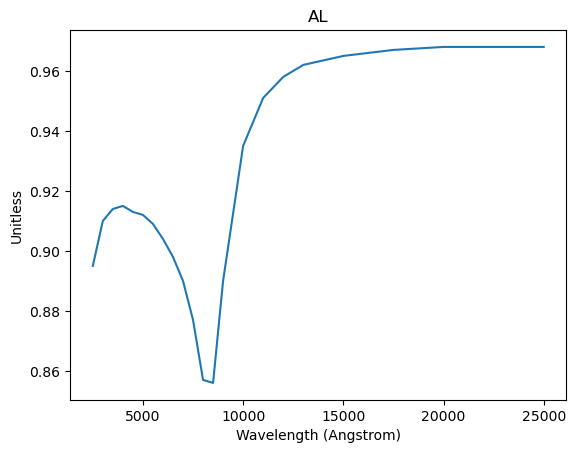

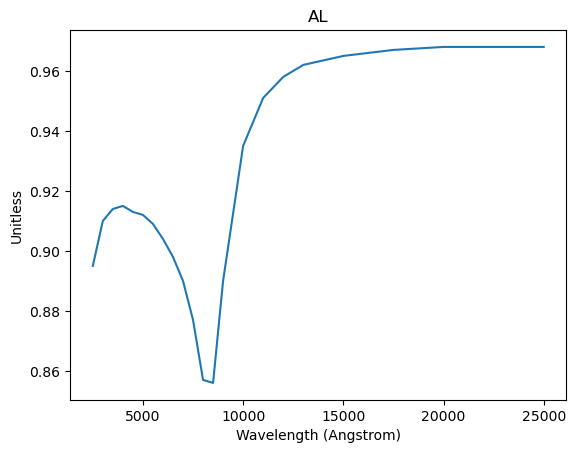

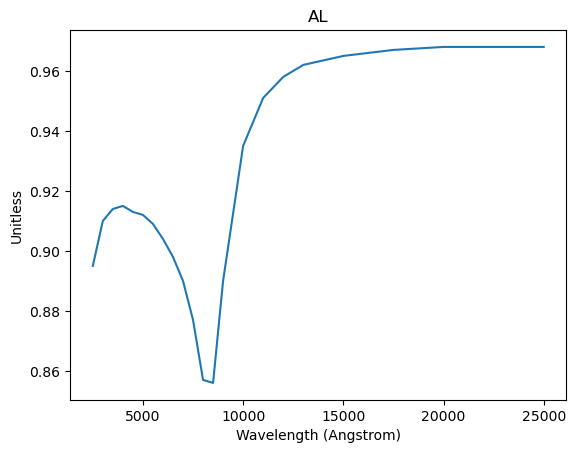

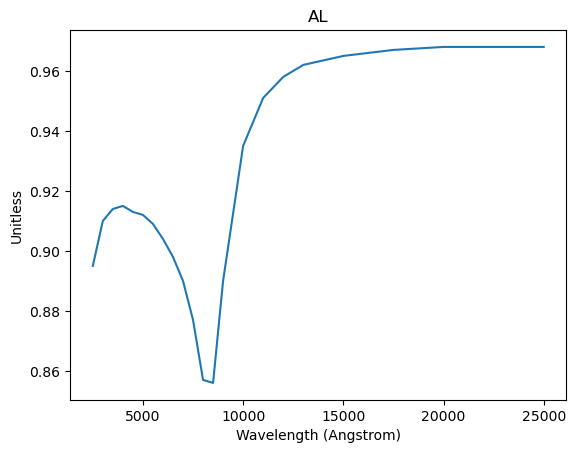

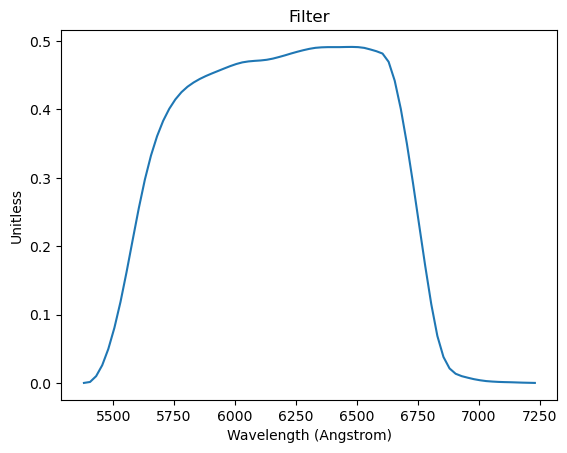

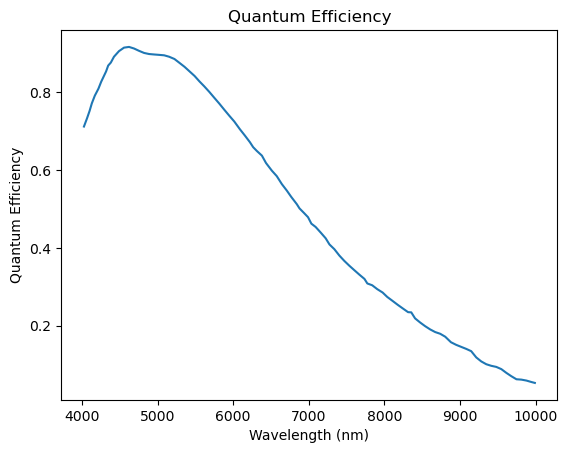

In [2]:
WCC = wcc_etc.WCCETC("../config/config.toml")
WCC.setup(verbose=True)

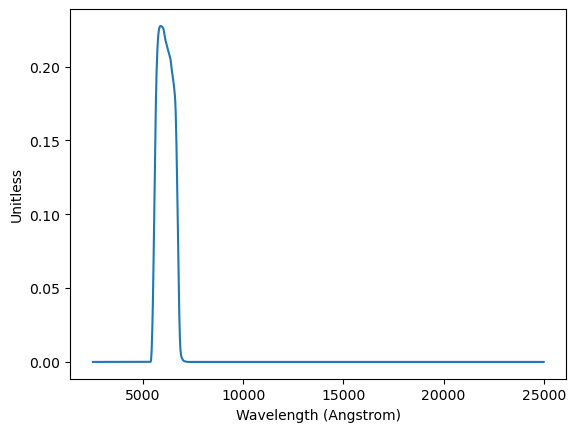

In [3]:
WCC.bandpass.plot()

# Calculate SNR for a given exposure time and magnitude

Source Counts: 1.6230700376026028 electron / s
Background Counts: 1.9324368731660874e-62 electron / s
########################
Saturation time: 360981.009 s
########################
Time to get to SNR=10.0: 382.428 s


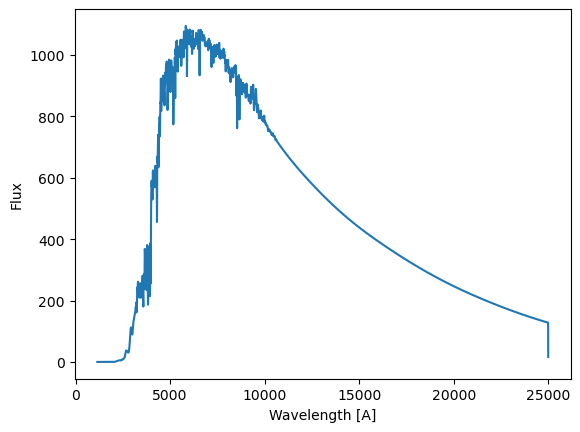

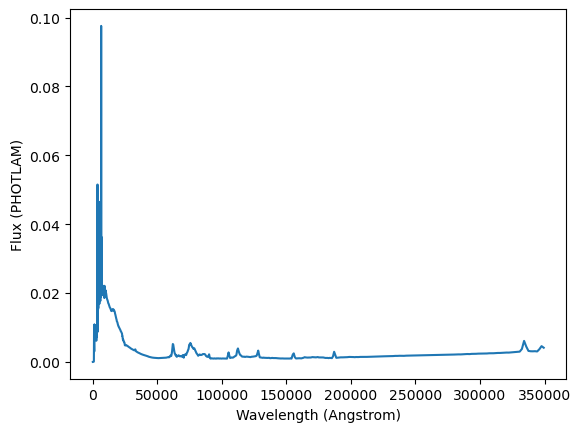

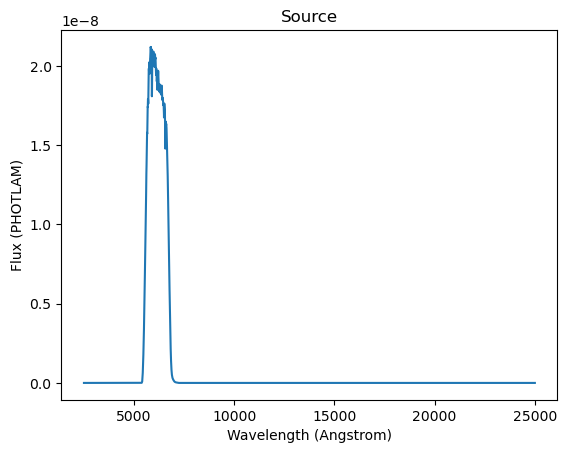

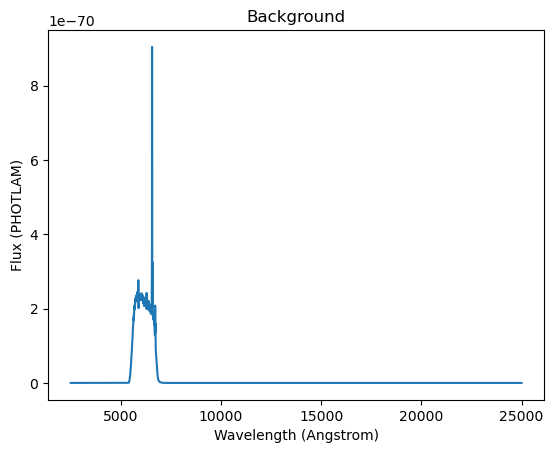

In [5]:
import os
from astropy import units as u
uasal_archive = os.environ.get("UASAL_ARCHIVE")

MAG = 25 # AB mag
BKG_MAG = 180 # vmag / arcsec2 # make background irrelevant
SNR = 10.
frame_time = 10. #
source_file = '/Users/gks/Dropbox/mypylib/notebooks/GIT/USAL_ARCHIVE/2025-06-16_uasal_archive_repo/astr_obj_models/stars/pickles_models/dat_uvk/pickles_uk_55.fits'
bkg_file = 'ngc_2537_spec.fits'

w, y = WCC.set_source(source_file,plot=True)

WCC.set_background(background_file=bkg_file,support_data_path=f'{uasal_archive}/astr_obj_models/galaxies/brown/', plot=True)
WCC.make_observation(flux=MAG, bg_flux=BKG_MAG, plot=True, verbose=True)

# Calculate the CCD's Saturation Time
print('########################')
sat_time = WCC.calc_saturation_time()
print('Saturation time: {:0.3f}'.format(sat_time))

# Calculate time to given SNR
print('########################')
t_int = WCC.calc_int_time(snr=SNR,exp_time=frame_time*u.s)
print('Time to get to SNR={}: {:0.3f}'.format(SNR,t_int))

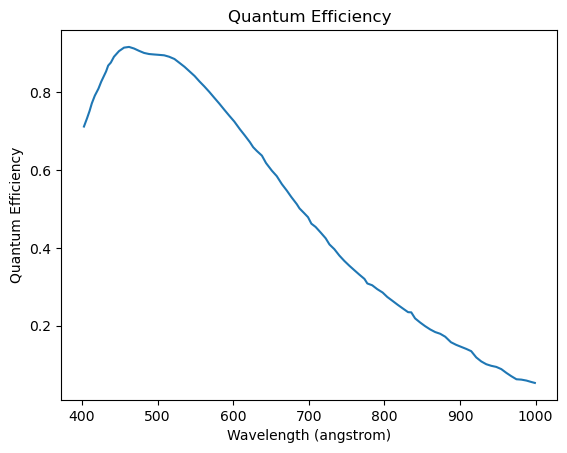

In [3]:
WCC.add_qe_curve("../data/support_data/sensors/ZWO_ASI6200MM/ZWO_ASI6200MM_Pro_QE_curve.csv", wave_unit='angstrom', num_curves=1, plot=True)

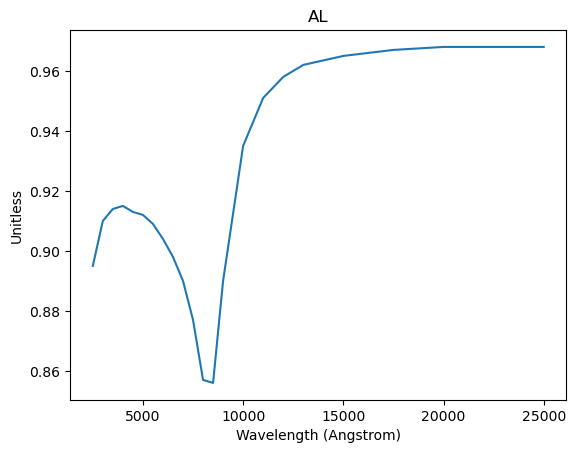

In [4]:
WCC.add_mirror("../data/support_data/coatings/NIST_1st_surface_Al.csv", num_curves=1, wave_unit='nm', plot=True, plot_title="AL")

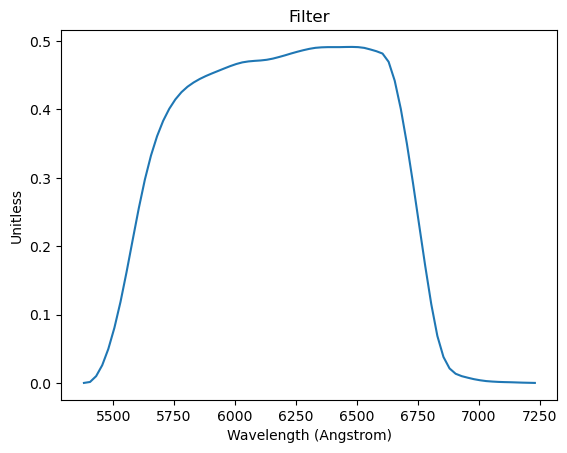

In [5]:
WCC.add_filter("../data/support_data/filters/sdss_r_005_syn.fits",plot=True)

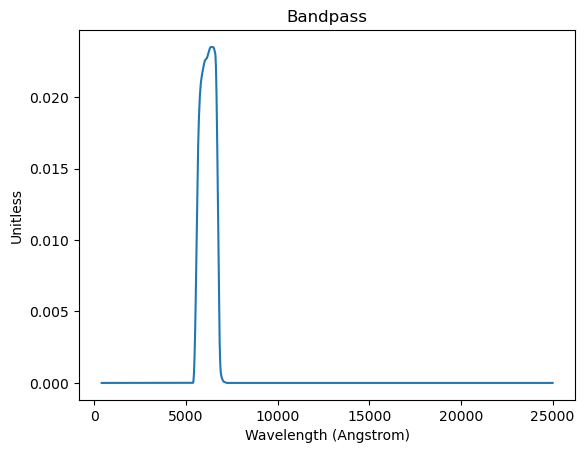

In [6]:
WCC.bandpass.plot(title="Bandpass")

In [25]:
WCC.tel_config

{'diameter': 3.0, 'f_ratio': 15.0}

In [27]:
WCC.config['detector']['gain'] 

1.0